In [1]:
# ================================================
# Notebook 02 — Exploratory Data Analysis (EDA)
# Battery Health Predictor | Ather Energy Project
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load preprocessed data from notebook 01
df = pd.read_csv(r'C:\Users\AmalDev\Downloads\final_features.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Data loaded successfully!
Shape: (1415, 14)
Columns: ['battery_id', 'cycle', 'voltage', 'temperature', 'capacity', 'soh', 'rul', 'health_label', 'degradation_pct', 'voltage_drop', 'soh_lag_1', 'soh_lag_3', 'temp_capacity', 'health_encoded']


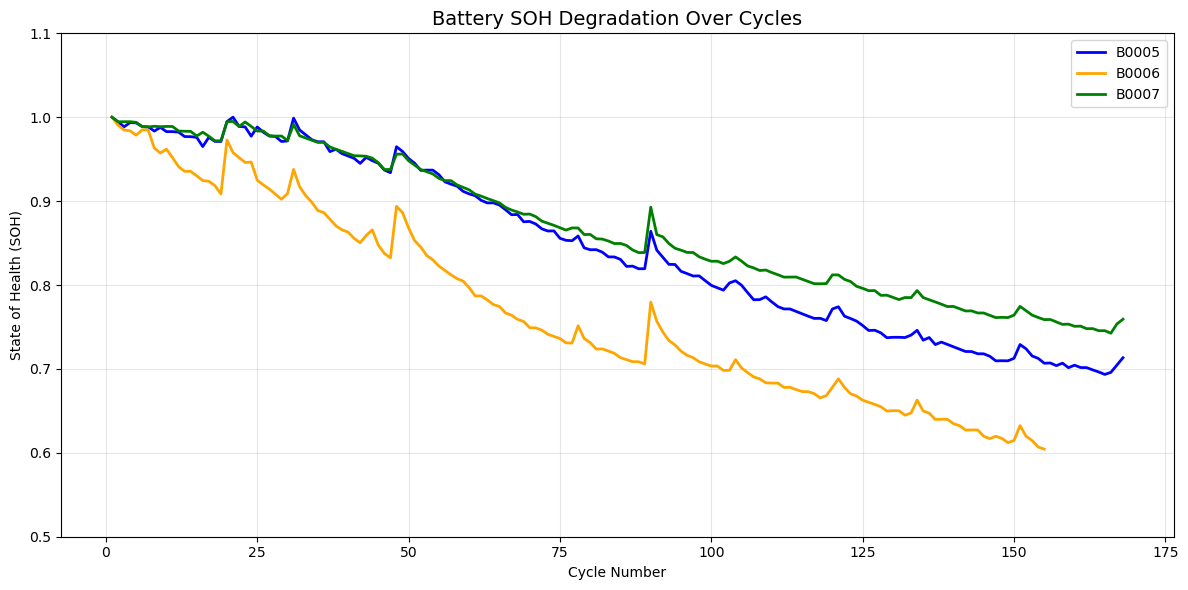

Chart 1 saved!


In [3]:
# Chart 1 - SOH degradation over cycles for top 3 batteries
plt.figure(figsize=(12, 6))

batteries = ['B0005', 'B0006', 'B0007']
colors = ['blue', 'orange', 'green']

for battery, color in zip(batteries, colors):
    data = df[df['battery_id'] == battery]
    plt.plot(data['cycle'], data['soh'],
             label=battery, color=color, linewidth=2)

plt.title('Battery SOH Degradation Over Cycles', fontsize=14)
plt.xlabel('Cycle Number')
plt.ylabel('State of Health (SOH)')
plt.ylim(0.5, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_soh_degradation.png', dpi=150)
plt.show()
print("Chart 1 saved!")

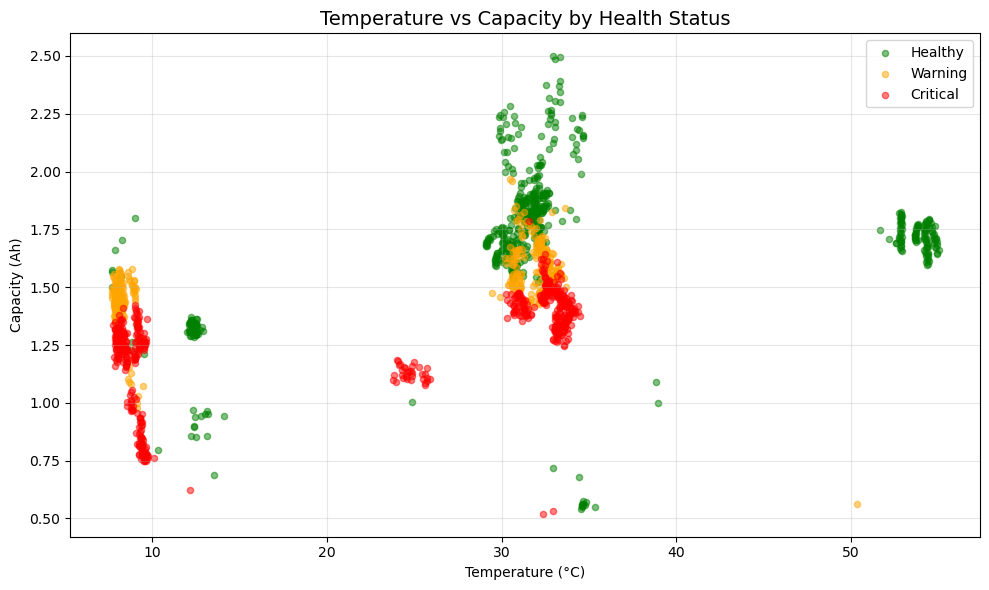

Chart 2 saved!


In [5]:
# Chart 2 - Temperature vs Capacity scatter plot
plt.figure(figsize=(10, 6))

colors_map = {'Healthy': 'green', 'Warning': 'orange', 'Critical': 'red'}

for label, color in colors_map.items():
    subset = df[df['health_label'] == label]
    plt.scatter(subset['temperature'], subset['capacity'],
                c=color, label=label, alpha=0.5, s=20)

plt.title('Temperature vs Capacity by Health Status', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Capacity (Ah)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_temp_vs_capacity.png', dpi=150)
plt.show()
print("Chart 2 saved!")

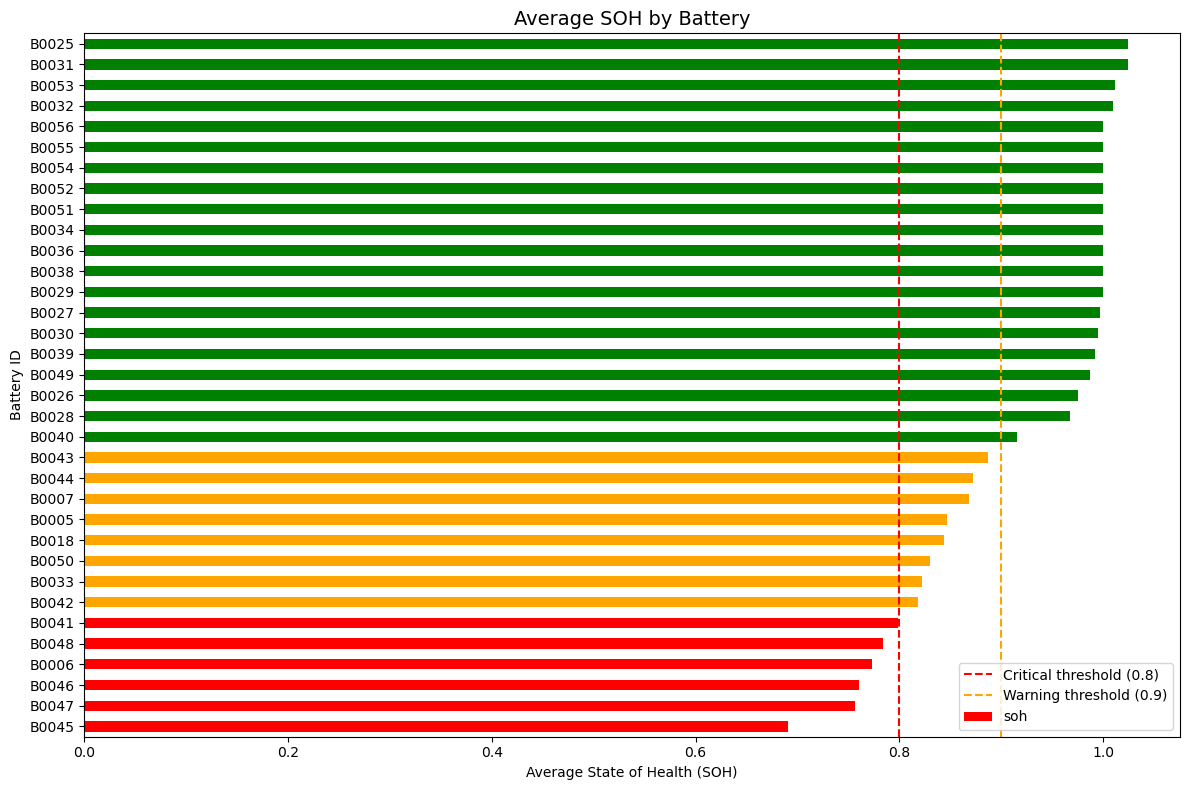

Chart 3 saved!


In [7]:
# Chart 3 - Average SOH by battery
avg_soh = df.groupby('battery_id')['soh'].mean().sort_values()

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0.8 else 'orange' if x < 0.9 else 'green' 
          for x in avg_soh.values]

avg_soh.plot(kind='barh', color=colors, figsize=(12, 8))
plt.title('Average SOH by Battery', fontsize=14)
plt.xlabel('Average State of Health (SOH)')
plt.ylabel('Battery ID')
plt.axvline(x=0.8, color='red', linestyle='--', 
            linewidth=1.5, label='Critical threshold (0.8)')
plt.axvline(x=0.9, color='orange', linestyle='--', 
            linewidth=1.5, label='Warning threshold (0.9)')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_avg_soh_by_battery.png', dpi=150)
plt.show()
print("Chart 3 saved!")

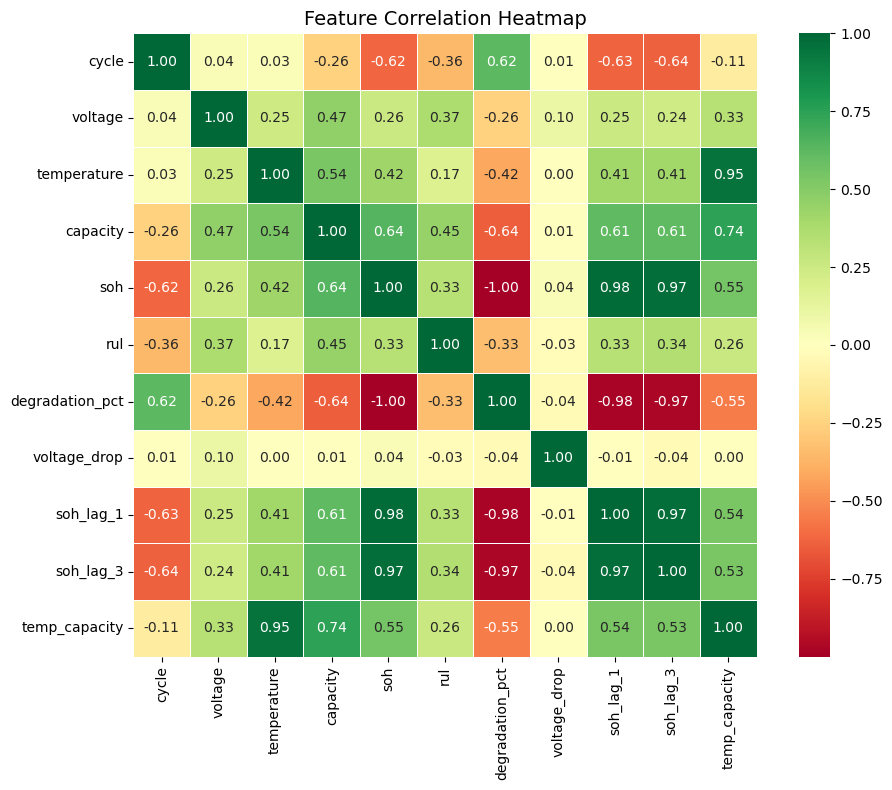

Chart 4 saved!


In [9]:
# Chart 4 - Correlation heatmap
plt.figure(figsize=(10, 8))

numeric_cols = ['cycle', 'voltage', 'temperature', 'capacity', 
                'soh', 'rul', 'degradation_pct', 'voltage_drop',
                'soh_lag_1', 'soh_lag_3', 'temp_capacity']

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 4 saved!")

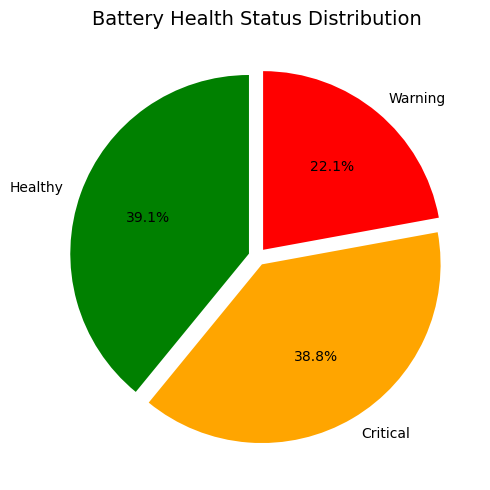

Chart 5 saved!


In [11]:
# Chart 5 - Health status distribution
plt.figure(figsize=(8, 5))

health_counts = df['health_label'].value_counts()
colors = ['green', 'orange', 'red']

plt.pie(health_counts.values,
        labels=health_counts.index,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05, 0.05))

plt.title('Battery Health Status Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('chart5_health_distribution.png', dpi=150)
plt.show()
print("Chart 5 saved!")